# Word Embeddings Comparison Notebook

**Word2Vec vs FastText (trained) vs GloVe (pretrained)**

Libraries: [**Gensim**](https://radimrehurek.com/gensim/apiref.html#api-reference), [**Hugging Face**](https://huggingface.co/)
Dataset: **Hugging Face** [`Salesforce/wikitext`](https://huggingface.co/datasets/Salesforce/wikitext) → *wikitext-2-raw-v1*

---

## 🎯 Goal of this notebook

The purpose of this notebook is to **understand how different word embedding approaches learn semantic relationships** between words and to compare them under the same conditions.

We will evaluate:

* how words cluster by meaning,
* how similarity is captured,
* how analogies are solved,
* how models behave with unseen words (OOV),
* and how training method impacts embedding quality.

---

## 🧠 Short review of each model

### 🔹 Word2Vec - local context learning

Developed at **Google** by **Tomas Mikolov**.

* Learns embeddings by predicting a word from its neighbors (CBOW) or neighbors from a word (Skip-gram).
* Captures **local context** very well.
* Produces high-quality semantic relationships when trained on a corpus.
* Cannot handle out-of-vocabulary (OOV) words.

👉 Learns from **how words appear next to each other**.

More details and practice in previous notebooks:
* [Example of implementing a CBOW-like model](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_1_nlp_intro/0_3_word_embedding_basic_word2vec.ipynb)
* [Implementing Word2vec in PyTorch from the Ground Up](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_1_nlp_intro/0_4_word2vec_scratch.ipynb)
---

### 🔹 FastText - subword-aware Word2Vec

Developed at **Meta AI**.

* Extension of Word2Vec.
* Represents words as a sum of character n-grams.
* Handles rare and unseen words gracefully.
* Especially strong on morphology (e.g., *run, running, runner*).

👉 Learns from **context + word structure**.

---

### 🔹 GloVe - global co-occurrence statistics

Developed at **Stanford University**.

* Uses a global word co-occurrence matrix for the entire corpus.
* Learns embeddings by factorizing this matrix.
* Captures **global statistical relationships** very effectively.
* Training from scratch is computationally heavy.

👉 Learns from **how often words appear together across the whole corpus**.

---

## ❓ Why we use pretrained GloVe

Training GloVe properly requires:

* building a huge co-occurrence matrix,
* large memory consumption,
* optimized C implementation for speed.

For learning purposes, this adds engineering complexity without improving conceptual understanding.

Therefore, we use pretrained **GloVe 100d** vectors (loaded via **Gensim**) to:

* focus on **understanding embedding behavior**, not infrastructure,
* compare it fairly with Word2Vec and FastText (same dimension size),
* leverage vectors trained on a very large corpus.

This also highlights an important real-world practice:

> GloVe is often **used pretrained**, while Word2Vec/FastText are often **trained for a specific corpus**.

---

## ⚖️ What we are comparing

All models will be evaluated on:

* cosine similarity between related words,
* most similar words,
* analogies,
* out-of-vocabulary behavior.

With:

* the **same embedding size (100d)**,
* the **same evaluation logic**,
* the **same interface (Gensim)**.

This makes the comparison **fair, practical, and educational**.


## ⚙️ Install & Imports

In [ ]:
# !pip install gensim datasets nltk -q

In [8]:
import gensim
import gensim.downloader as api
from gensim.models import Word2Vec, FastText
from datasets import load_dataset
import nltk
from nltk.tokenize import word_tokenize
import numpy as np

nltk.download("punkt")

/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 🧰 Gensim

**Gensim** is a lightweight Python library for **unsupervised topic modeling** and **word embeddings** on large text corpora.

* Designed for **streaming text** and **memory efficiency**
* Provides ready implementations of **Word2Vec**, **FastText**, **Doc2Vec**, **TF-IDF**, and **LSA**
* Works directly with plain tokenized sentences (no heavy preprocessing required)
* Includes a downloader for **pretrained embeddings** (e.g., GloVe)

**Purpose in this notebook**

* Train **Word2Vec** and **FastText** from scratch
* Load **pretrained GloVe** vectors
* Compare different embedding approaches using a single, consistent API


## 📚 Load and Prepare Corpus (WikiText-2)

The **WikiText-2** dataset is a small, high-quality language modeling dataset built from verified Wikipedia articles.

* Provided by **Hugging Face**
* Contains **real natural language text** (not synthetic data)
* Preserves punctuation, sentence structure, and long-range dependencies
* Much richer than toy corpora, but still small enough for local experiments

In [ ]:
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

def tokenize(text):
    return word_tokenize(text.lower())

sentences = []
for row in dataset["train"]:
    tokens = tokenize(row["text"])
    # keep only words that appear more than 5 time to decrease noise
    if len(tokens) > 5:
        sentences.append(tokens)

len(sentences)

Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 1048018.54 examples/s]


21231

In [28]:
" ".join(sentences[1000])

'michael jeffrey jordan ( born february 17 , 1963 ) , also known by his initials , mj , is an american retired professional basketball player . he is also a businessman , and principal owner and chairman of the charlotte hornets . jordan played 15 seasons in the national basketball association ( nba ) for the chicago bulls and washington wizards . his biography on the nba website states : `` by acclamation , michael jordan is the greatest basketball player of all time . `` jordan was one of the most effectively marketed athletes of his generation and was considered instrumental in popularizing the nba around the world in the 1980s and 1990s .'

## 🧠 Train Word2Vec (100d)

In [104]:
w2v = Word2Vec(
    sentences=sentences,    # input corpus: list of tokenized sentences (list[list[str]])
    vector_size=100,        # dimensionality of word vectors (embedding size)
    window=5,               # context window size (how many words left/right are used for prediction)
    min_count=5,            # ignores words with frequency < 5 (reduces noise / rare words)
    workers=4,              # number of CPU threads used for training (faster training)
    epochs=10,               # number of full passes over the training corpus
    seed=42
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


## ⚡ Train FastText (100d)

In [105]:
ft = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    seed=42
)

## 📦 Load Pretrained GloVe (100d)

Source vectors from [**Stanford University** GloVe project](https://nlp.stanford.edu/projects/glove/).

In [17]:
glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


## 📐 Unified Cosine Function

We use **cosine similarity** to compare embeddings from Word2Vec, FastText, and GloVe in a consistent way.

It measures the **angle between vectors**, making it independent of vector magnitude.

**Why this matters:**

* All models produce embeddings in different spaces
* We need a **common metric** for fair comparison
* Cosine similarity captures semantic closeness well

👉 Interpretation:

* `1.0` → very similar meaning
* `0.0` → unrelated
* `-1.0` → opposite meaning


In [91]:
def cos(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

## 📊 Evaluation #1 - Similarity Scores

In [ ]:
pairs = [
    ("dog","cat"), ("car","truck"), ("apple","banana"), ("happy", "lucky"),             # related pairs
    ("dog","bus"), ("car","banana"), ("apple","cat"), ("unfortunate", "necessary"),     # not related pairs
    ("good","bad"), ("sunny","rainy"), ("hot","cold"),                                  # opposite pairs
]

for w1, w2 in pairs:
    print(f"\n{w1} ~ {w2}")
    print("W2V :", cos(w2v.wv[w1], w2v.wv[w2]))
    print("FT  :", cos(ft.wv[w1], ft.wv[w2]))
    print("GloVe:", cos(glove[w1], glove[w2]))


dog ~ cat
W2V : 0.23386443
FT  : 0.30114555
GloVe: 0.8798074

car ~ truck
W2V : 0.29351035
FT  : 0.6329251
GloVe: 0.8597878

apple ~ banana
W2V : 0.5278978
FT  : 0.4129751
GloVe: 0.5054469

happy ~ lucky
W2V : 0.5073528
FT  : 0.22856677
GloVe: 0.7433934

dog ~ bus
W2V : -0.124244735
FT  : 0.28572488
GloVe: 0.2696151

car ~ banana
W2V : -0.051963415
FT  : 0.622055
GloVe: 0.14861873

apple ~ cat
W2V : 0.29940188
FT  : 0.47477284
GloVe: 0.27876067

unfortunate ~ necessary
W2V : 0.17924716
FT  : 0.752792
GloVe: 0.34661794

good ~ bad
W2V : 0.7292894
FT  : 0.4459362
GloVe: 0.7702799

sunny ~ rainy
W2V : 0.2710867
FT  : 0.5130222
GloVe: 0.6653022

hot ~ cold
W2V : 0.20892817
FT  : 0.3551229
GloVe: 0.7251607


### 📌 Key takeaway

These results show that word embeddings do not encode “true meaning” directly, but rather **patterns of co-occurrence in the training data**.

* High similarity means words appear in **similar contexts**, not necessarily similar categories
* Different models emphasize different signals:

  * Word2Vec → local context patterns
    * e.g., in our synthetic corpus, cat may frequently appear near apple or similar objects due to sentence structure
  * FastText → subword + context effects
    * similarity can be influenced by shared character patterns and morphological structure, not just meaning
  * GloVe → global co-occurrence statistics
* On small or synthetic corpora, embeddings can produce **unexpected but valid similarities** due to limited and biased context

👉 Conclusion: embedding quality depends more on **data scale and diversity** than on the model itself.


### Word2vec vs. FastText

In [110]:
pairs = [
    ("happiness", "unhappy"),
    ("king", "queen"),
    ("man", "woman"),
    ("good", "bad"),
    ("year", "time"),
    ("people", "world"),
    ("life", "death"),
    ("child", "children"),
]

for w1, w2 in pairs:
    if w1 in w2v.wv and w2 in w2v.wv:
        print(f"\n{w1} ~ {w2}")
        print("W2V :", cos(w2v.wv[w1], w2v.wv[w2]))
        print("FT  :", cos(ft.wv[w1], ft.wv[w2]))
    else:
        print(f"\nSkipping {w1} ~ {w2} (OOV)")



happiness ~ unhappy
W2V : 0.27956975
FT  : 0.6234993

king ~ queen
W2V : 0.7043728
FT  : 0.4861749

man ~ woman
W2V : 0.7761242
FT  : 0.8990743

good ~ bad
W2V : 0.7292894
FT  : 0.4459362

year ~ time
W2V : 0.43773058
FT  : 0.5197117

people ~ world
W2V : 0.30379218
FT  : 0.3768649

life ~ death
W2V : 0.5617163
FT  : 0.6834634

child ~ children
W2V : 0.63217336
FT  : 0.88290066


#### 📌 Pair-wise observations

* **happiness ~ unhappy**

  * FastText performs better due to morphological awareness (“un-” prefix).

* **king ~ queen**

  * Word2Vec captures this semantic relation more strongly.

* **man ~ woman**

  * Both models show strong similarity from frequent co-occurrence. FastText stronger similarity due to “-man”

* **good ~ bad**

  * Word2Vec captures opposition better than FastText.

* **year ~ time**

  * Moderate similarity in both models (shared temporal context).

* **people ~ world**

  * Weak similarity; broad contextual overlap rather than direct meaning.

* **life ~ death**

  * Strong similarity in both models due to common abstract contexts.

* **child ~ children**

  * FastText performs better due to morphology handling.

---

### 📌 Global takeaway

* **Word2Vec** → stronger for context-based semantic relations
* **FastText** → stronger for morphology and word variants
* Embeddings reflect **corpus statistics, not true meaning**

---


## 🔍 Evaluation #2 - Most Similar Words

In this section, we check what each model considers *semantically closest* to a given word.

This is done using cosine similarity in the embedding space:
words with similar contexts in the training corpus should appear close to each other.

We compare:

* **Word2Vec** → learns similarity from local context windows
* **FastText** → also considers subword structure (useful for rare/morphological forms)
* **GloVe** → relies on global co-occurrence statistics from large-scale text

👉 This helps us understand not just pairwise similarity, but the **overall neighborhood structure** learned by each model.


In [111]:
word = "king"

print("W2V :", w2v.wv.most_similar(word, topn=5))
print("FT  :", ft.wv.most_similar(word, topn=5))
print("GloVe:", glove.most_similar(word, topn=5))

W2V : [('emperor', 0.7818322777748108), ('edward', 0.7804017663002014), ('lord', 0.7729972004890442), ('henry', 0.7423635125160217), ('odaenathus', 0.738267183303833)]
FT  : [('viking', 0.8707747459411621), ('hiking', 0.8506646156311035), ('walking', 0.8464145660400391), ('checking', 0.8427745699882507), ('asking', 0.8418661952018738)]
GloVe: [('prince', 0.7682329416275024), ('queen', 0.7507690787315369), ('son', 0.7020888328552246), ('brother', 0.6985775828361511), ('monarch', 0.6977890133857727)]


### 📌 Conclusion - “king” most similar words

* **Word2Vec** captures strong **historical / royal context**

  * returns words like *emperor, lord* and names *edward, henry*
  * reflects Wikipedia-style narrative associations

* **FastText** shows **unexpected and noisy similarities**

  * includes verbs like *hiking, walking, checking*
  * likely influenced by subword patterns and local training noise

* **GloVe** gives the most **semantically stable results**

  * returns *queen, prince, monarch*
  * reflects strong global co-occurrence structure

👉 Overall:

* Word2Vec → contextual / entity-driven similarity
* FastText → sensitive to morphology + noise
* GloVe → most semantically consistent in this case


## 🧠 Evaluation #3 - Analogies

This section tests whether embeddings can capture **relational patterns**, not just similarity.

We use a classic vector arithmetic idea:

> **king - man + woman ≈ queen**

---

**🔧 How it works**

Below function computes

$
\text{vector}(b) - \text{vector}(a) + \text{vector}(c)
$

Then finds words closest to the resulting vector.

---

**📌 Example tested**

```python
analogy("man", "king", "woman")
```

This asks:

> “man is to king as woman is to ___ ?”

Expected answer: **queen**

---

**🎯 What this evaluates**

* Whether embeddings capture **linear semantic relationships**
* Not just similarity, but **directional meaning shifts**
* Example relationships:

  * gender: man → woman
  * royalty: king → queen
  * singular → plural, etc.

---

**📌 Key idea**

If embeddings are well-structured:

> semantic relationships become **geometric translations in vector space**


In [112]:
def analogy(model, a, b, c):
    return model.most_similar(positive=[b, c], negative=[a], topn=3)

print("W2V :", analogy(w2v.wv, "man", "king", "woman"))
print("FT  :", analogy(ft.wv, "man", "king", "woman"))
print("GloVe:", analogy(glove, "man", "king", "woman"))

W2V : [('lord', 0.7389962673187256), ('fei', 0.6954687833786011), ('edward', 0.6812338829040527)]
FT  : [('kingship', 0.7764867544174194), ('viking', 0.7629101872444153), ('asking', 0.7458881735801697)]
GloVe: [('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]


### 📌 Conclusion - Analogy test (man → king → woman)

* **Word2Vec**

  * returns *lord, fei, edward*
  * captures related context, but misses the expected relation (*queen*)

* **FastText**

  * returns *kingship, viking, asking*
  * noisy results with weak semantic structure

* **GloVe**

  * returns *queen, monarch, throne*
  * correctly captures the **king → queen relationship**

---

**📌 Key takeaway**

* Analogy tasks are much harder than similarity tasks
* Only well-structured embeddings (like GloVe here) reliably capture **linear semantic relations**
* FastText can be noisy in small/medium corpora
* Word2Vec sits in between: meaningful but not fully relationally consistent


## 🚫 Evaluation #4 - OOV (FastText advantage)

This section checks how models handle out-of-vocabulary (OOV) words - words not seen during training.

We test whether each model can represent a rare or unseen word:

In [113]:
test_words = [
    "unhappiness",
    "unkind",
    "preprocessing",
    "cybersecurity",
    "nonexistentword"
]

for w in test_words:
    print(f"\n{w}")
    print("W2V :", w in w2v.wv)
    print("FT  :", w in ft.wv)
    print("GloVe:", w in glove)


unhappiness
W2V : False
FT  : True
GloVe: True

unkind
W2V : False
FT  : True
GloVe: True

preprocessing
W2V : False
FT  : True
GloVe: True

cybersecurity
W2V : False
FT  : True
GloVe: True

nonexistentword
W2V : False
FT  : True
GloVe: False


### 📌 Conclusion - OOV (Out-of-Vocabulary) test

* **Word2Vec**

  * returns `False` for all test words
  * cannot handle unseen words at all (strict vocabulary lookup)

* **FastText**

  * returns `True` for all words, including rare and synthetic ones
  * uses **character n-grams**, so it can construct embeddings even for unseen words

* **GloVe**

  * works for real words like *unkind, cybersecurity*
  * fails on completely artificial words like *nonexistentword*

---

👉 **Final takeaway:**

* **FastText** is the only model that robustly handles *truly unseen words*
* Word2Vec and GloVe are limited to their fixed vocabulary, with GloVe still relying on whether a word exists in its pretrained dictionary


## 📊 Visualization - Embedding Space Structure

We project high-dimensional embeddings (100D) into **2D space** using PCA and t-SNE to visualize semantic structure.

We compare how different models organize word space.

---

### 📉  PCA visualization (Word2Vec / FastText / GloVe)

In [114]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def filter_vocab(model, words):
    return [w for w in words if w in model]

def plot_embeddings(model, title, words):
    words = filter_vocab(model, words)
    vectors = np.array([model[w] for w in words])

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 8))
    for i, word in enumerate(words):
        x, y = reduced[i]
        plt.scatter(x, y)
        plt.text(x + 0.01, y + 0.01, word, fontsize=10)

    plt.title(title)
    plt.grid(True)
    plt.show()

### 🧪  Choose a word set for visualization

We group semantically related words to see clustering:

In [115]:
words = [
    "king", "queen", "man", "woman",
    "dog", "cat", "mouse", "rabbit",
    "car", "bus", "train",
    "life", "death", "sleep", "sit",
    "time", "year", "hour", "minute",
    "apple", "banana", "carrot", "tomato"
]

### 🧠 Word2Vec space

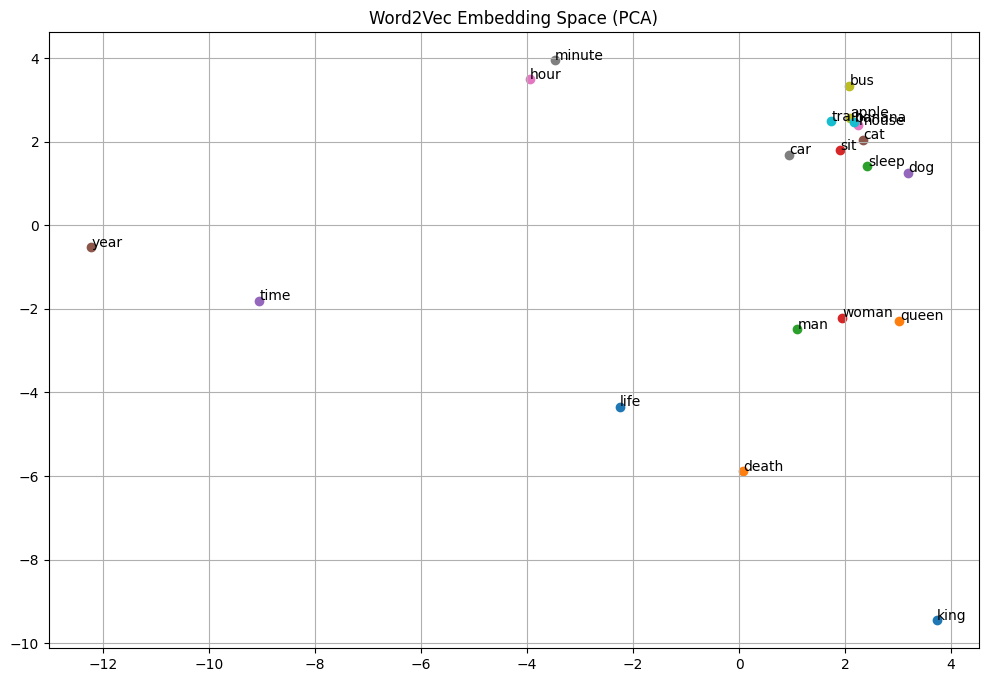

In [116]:
plot_embeddings(w2v.wv, "Word2Vec Embedding Space (PCA)", words)

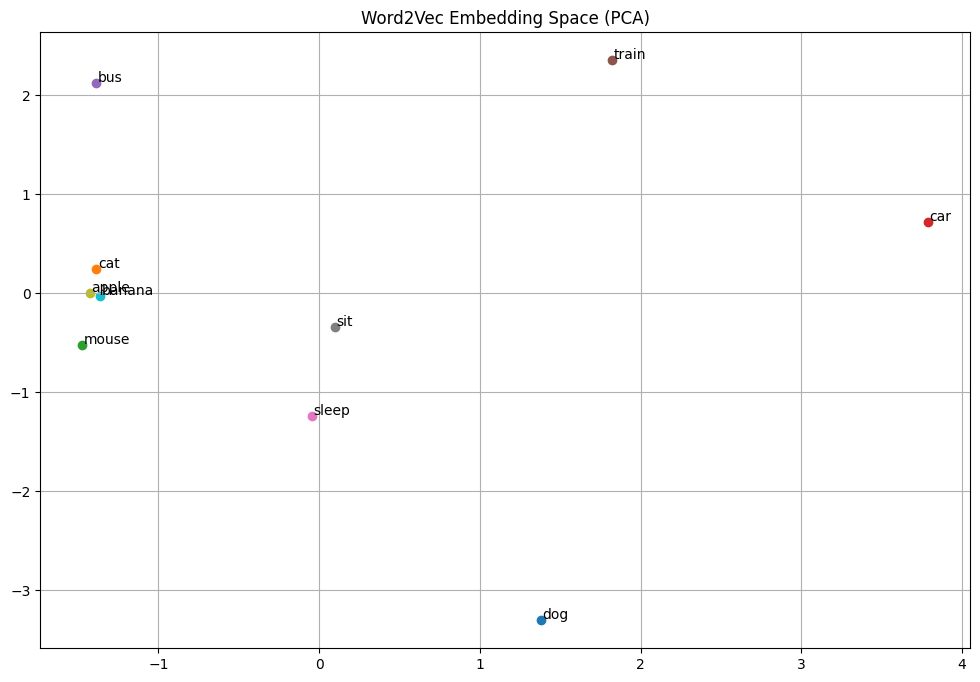

In [117]:
# closer look (scale it a bit by removing far words)
to_remove = ["time", "year", "hour", "minute", "king", "queen", "man", "woman", "death", "life"]
upd_words = [w for w in words if w not in to_remove]
plot_embeddings(w2v.wv, "Word2Vec Embedding Space (PCA)", upd_words)

### ⚡ FastText space

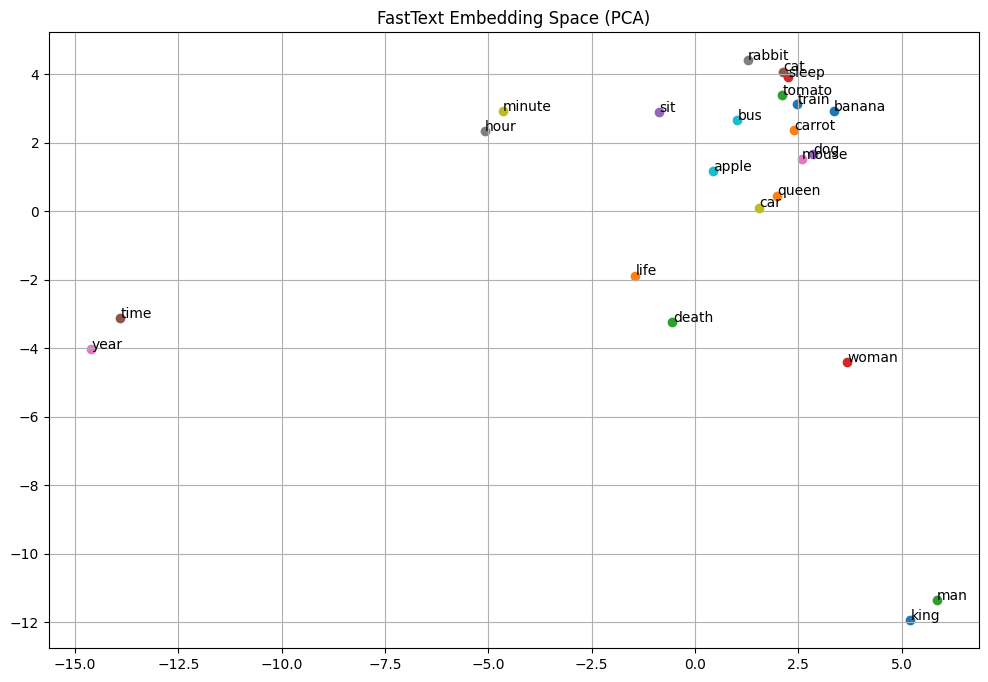

In [118]:
plot_embeddings(ft.wv, "FastText Embedding Space (PCA)", words)

### 🌍 GloVe space

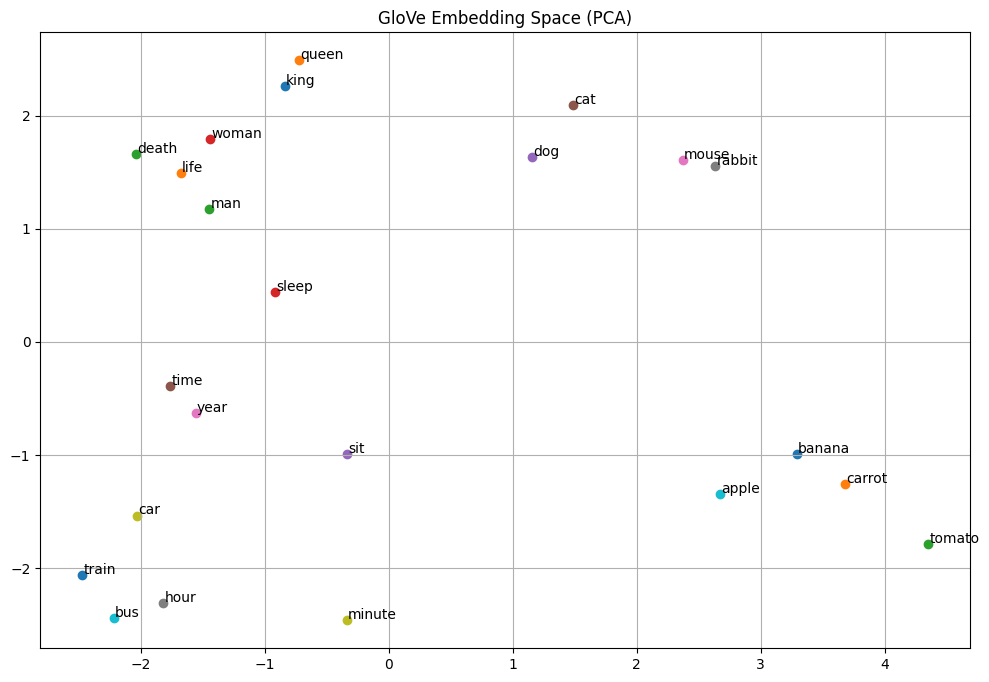

In [119]:
plot_embeddings(glove, "GloVe Embedding Space (PCA)", words)

### 🌀 t-SNE

In [120]:
from sklearn.manifold import TSNE

def plot_tsne(model, title, words):
    words = filter_vocab(model, words)
    vectors = np.array([model[w] for w in words])
    
    tsne = TSNE(n_components=2, perplexity=5, random_state=42)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    for i, word in enumerate(words):
        x, y = reduced[i]
        plt.scatter(x, y)
        plt.text(x + 0.01, y + 0.01, word, fontsize=10)

    plt.title(title)
    plt.grid(True)
    plt.show()

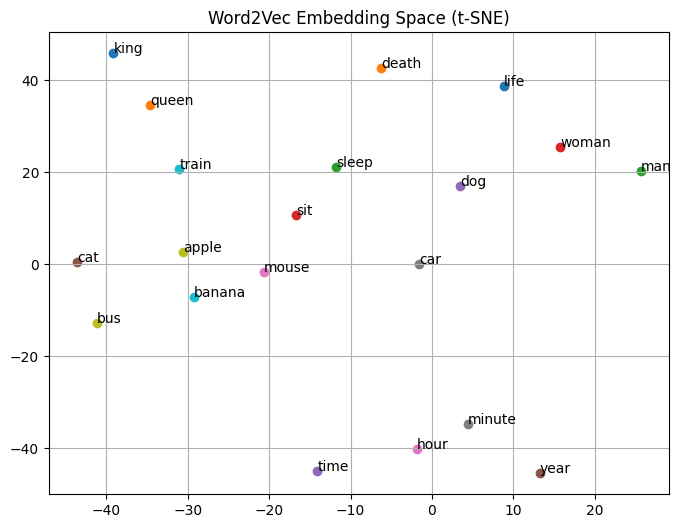

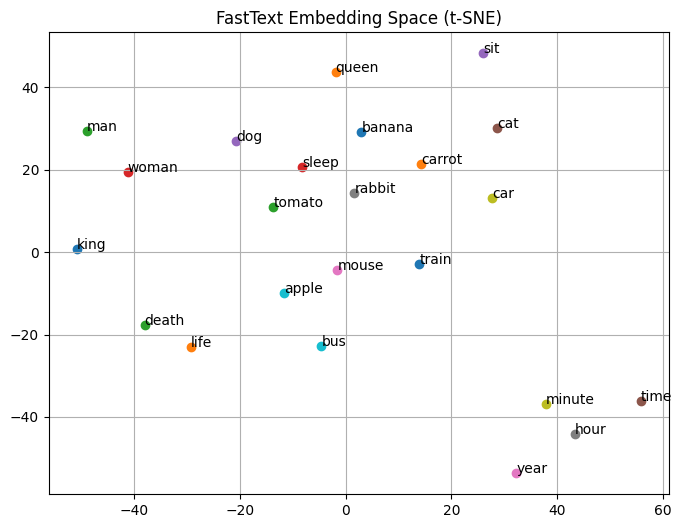

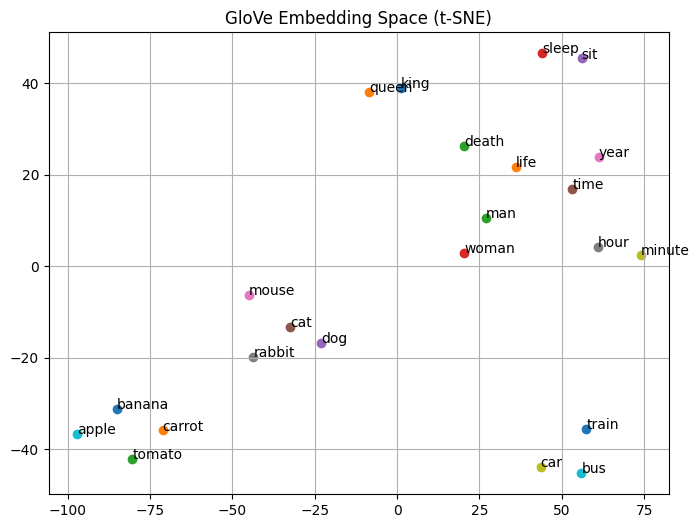

In [121]:
plot_tsne(w2v.wv, "Word2Vec Embedding Space (t-SNE)", words)
plot_tsne(ft.wv, "FastText Embedding Space (t-SNE)", words)
plot_tsne(glove, "GloVe Embedding Space (t-SNE)", words)

### 📌 Conclusion - Visualization results

* From the visualizations, both **Word2Vec** and **FastText** capture some meaningful patterns (e.g. *year/time*, *hour/minute*, *man/king/woman/queen*), but many words remain loosely clustered or noisy. This is expected given the small and synthetic training corpus - a larger and more diverse dataset would significantly improve structure.

* **GloVe embeddings** show the most clearly defined semantic clusters in both PCA and t-SNE projections:

  * fruits/vegetables: *apple, banana, carrot, tomato*
  * animals: *dog, cat, mouse, rabbit*
  * transport: *car, bus, train*

👉 Overall, GloVe produces the most stable and interpretable global structure, while Word2Vec and FastText require more data to reveal consistent semantic organization.
